In [1]:
import os
import numpy as np
import pandas as pd

from collections import defaultdict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, GRU, SimpleRNN, Dense, Dropout, BatchNormalization, Input, RepeatVector, TimeDistributed)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


In [2]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
dataset_path = "/content/drive/MyDrive/Pattern Recognition/sensory_data/HAR_PR_dataset_ver2"
examples_dir = os.path.join(dataset_path, "examples")
labels_dir   = os.path.join(dataset_path, "labels")


In [4]:
dataset_path = "/content/drive/MyDrive/Pattern Recognition/sensory_data/HAR_PR_dataset_ver2/examples"

all_folders = sorted(os.listdir(dataset_path))
session_folders = [f for f in all_folders if f.endswith("_extracted")]

activity_map = {
    "bending":       lambda f: "bending" in f.lower() and "stand" not in f.lower(),
    "bring":         lambda f: "bring" in f.lower(),
    "clean_floor":   lambda f: "clean_floor" in f.lower(),
    "clean_surface": lambda f: "clean_surface" in f.lower(),
    "drink":         lambda f: "drink" in f.lower(),
    "eat":           lambda f: "eatsmall" in f.lower(),
    "dry":           lambda f: "dryoff" in f.lower() and "shake" not in f.lower() and "byshake" not in f.lower(),
    "standing":      lambda f: "standing" in f.lower(),
    "sitting":       lambda f: "sitting" in f.lower(),
    "walking":       lambda f: "walking" in f.lower(),
    "lying":         lambda f: "lying" in f.lower(),
    "squatting":     lambda f: "squatting" in f.lower() and "standup" not in f.lower() and "standsquat" not in f.lower(),
}

def get_subject(folder_name):
    return folder_name.split("_")[0]

def get_activity(folder_name):
    for activity, match_fn in activity_map.items():
        if match_fn(folder_name):
            return activity
    return None

def count_events(session_path):
    files = os.listdir(session_path)
    event_ids = set()
    for f in files:
        if "_Event_" in f:
            event_id = f.split("_Event_")[1].replace(".data", "")
            event_ids.add(event_id)
    return len(event_ids)

# Build stats
subject_stats = defaultdict(lambda: {"activities": defaultdict(int), "total_events": 0, "sessions": 0})

for session in session_folders:
    subject  = get_subject(session)
    activity = get_activity(session)
    if activity is None:
        continue
    session_path = os.path.join(dataset_path, session)
    events = count_events(session_path)
    subject_stats[subject]["activities"][activity] += 1
    subject_stats[subject]["total_events"] += events
    subject_stats[subject]["sessions"] += 1

# Print summary
subjects = sorted(subject_stats.keys())
print(f"Total subjects: {len(subjects)}")
print(f"Total sessions: {sum(s['sessions'] for s in subject_stats.values())}")
print(f"Total events:   {sum(s['total_events'] for s in subject_stats.values())}")

print("\n" + "="*70)
for subject in subjects:
    stats = subject_stats[subject]
    print(f"\nSubject: {subject}")
    print(f"  Sessions : {stats['sessions']}")
    print(f"  Events   : {stats['total_events']}")
    print(f"  Activities ({len(stats['activities'])}):")
    for act, count in sorted(stats['activities'].items()):
        print(f"    {act:<15} : {count} session(s)")
print("="*70)

Total subjects: 9
Total sessions: 148
Total events:   1386


Subject: Adeel
  Sessions : 20
  Events   : 188
  Activities (10):
    bending         : 2 session(s)
    bring           : 2 session(s)
    drink           : 2 session(s)
    dry             : 2 session(s)
    eat             : 2 session(s)
    lying           : 2 session(s)
    sitting         : 2 session(s)
    squatting       : 2 session(s)
    standing        : 2 session(s)
    walking         : 2 session(s)

Subject: Frederic
  Sessions : 20
  Events   : 177
  Activities (10):
    bending         : 2 session(s)
    bring           : 2 session(s)
    drink           : 2 session(s)
    dry             : 2 session(s)
    eat             : 2 session(s)
    lying           : 2 session(s)
    sitting         : 2 session(s)
    squatting       : 2 session(s)
    standing        : 2 session(s)
    walking         : 2 session(s)

Subject: Huang
  Sessions : 22
  Events   : 200
  Activities (11):
    bending         : 2 session(s

In [5]:

sample_session = os.path.join(dataset_path, "Frederic_Standing1_extracted")
files = sorted(os.listdir(sample_session))
print(f"Total files in one session: {len(files)}")
print("\nUnique sensor types:")
sensor_types = sorted(set("_".join(f.split("_Event_")[0:1]) for f in files))
for s in sensor_types:
    print(f"  {s}")


# raw data structure of one file

print("\n--- Sample file content (JinsAccelerometer_Event_0.data) ---")
fpath = os.path.join(sample_session, "JinsAccelerometer_Event_0.data")
df = pd.read_csv(fpath, sep=";", header=None)
print(f"Shape: {df.shape}")
print(f"Columns: {df.shape[1]} (first=timestamp, rest=values)")
print(df.head(10).to_string())


# how many timestamp in one event file

print("\n--- Timesteps per event (JinsAccelerometer) ---")
for i in range(10):
    fpath = os.path.join(sample_session, f"JinsAccelerometer_Event_{i}.data")
    df = pd.read_csv(fpath, sep=";", header=None)
    print(f"  Event_{i}: {len(df)} timesteps")


# Timestamp of phone sensor

print("\n--- Timesteps per event (PhoneAccelerometer) ---")
for i in range(10):
    fpath = os.path.join(sample_session, f"PhoneAccelerometer_Event_{i}.data")
    df = pd.read_csv(fpath, sep=";", header=None)
    print(f"  Event_{i}: {len(df)} timesteps")


Total files in one session: 120

Unique sensor types:
  JinsAccelerometer
  JinsBlinkSpeed
  JinsBlinkStrength
  JinsEyeMovement
  JinsGyroscope
  PhoneAccelerometer
  PhoneGravity
  PhoneGyroscope
  PhoneLinearAccelerometer
  PhoneMagnetometer
  android.sensor.accelerometer
  android.sensor.gyroscope

--- Sample file content (JinsAccelerometer_Event_0.data) ---
Shape: (100, 4)
Columns: 4 (first=timestamp, rest=values)
               0    1    2     3
0  1519917086344  0.0  2.0 -15.0
1  1519917086347  0.0  2.0 -15.0
2  1519917086456  0.0  2.0 -15.0
3  1519917086458  0.0  2.0 -16.0
4  1519917086495  0.0  2.0 -15.0
5  1519917086531  0.0  2.0 -15.0
6  1519917086607  0.0  2.0 -15.0
7  1519917086644  0.0  2.0 -15.0
8  1519917086721  0.0  2.0 -15.0
9  1519917086760  0.0  2.0 -15.0

--- Timesteps per event (JinsAccelerometer) ---
  Event_0: 100 timesteps
  Event_1: 99 timesteps
  Event_2: 100 timesteps
  Event_3: 101 timesteps
  Event_4: 100 timesteps
  Event_5: 100 timesteps
  Event_6: 100 t

In [6]:
# Labels folder

labels_path = "/content/drive/MyDrive/Pattern Recognition/sensory_data/HAR_PR_dataset_ver2"
all_items = sorted(os.listdir(labels_path))
print("Root folder contents:")
for item in all_items:
    print(f"  {item}")

labels_dir = "/content/drive/MyDrive/Pattern Recognition/sensory_data/HAR_PR_dataset_ver2/labels"
if os.path.exists(labels_dir):
    label_files = sorted(os.listdir(labels_dir))
    print(f"Total label files: {len(label_files)}")
    print("\nFirst 10:")
    for f in label_files[:10]:
        print(f"  {f}")


    sample_label = os.path.join(labels_dir, label_files[0])
    print(f"\nContent of {label_files[0]}:")
    with open(sample_label, "r") as f:
        for i, line in enumerate(f):
            print(f"  {line.strip()}")
            if i > 10:
                break


Root folder contents:
  deleted_strange_HUAWEI_data.txt
  examples
  labels
Total label files: 6

First 10:
  label_info_both1.txt
  label_info_both2.txt
  label_info_left1.txt
  label_info_left2.txt
  label_info_right1.txt
  label_info_right2.txt

Content of label_info_both1.txt:
  Adeel_Bending_1_extracted 0 Bending
  Adeel_Bending_1_extracted 1 Bending
  Adeel_Bending_1_extracted 2 Bending
  Adeel_Bending_1_extracted 3 Bending
  Adeel_Bending_1_extracted 4 Bending
  Adeel_Bending_1_extracted 5 Bending
  Adeel_Bending_1_extracted 6 Bending
  Adeel_Bending_1_extracted 7 Bending
  Adeel_Bending_1_extracted 8 Bending
  Adeel_Bending_1_extracted 9 Bending
  Adeel_Bring_1_extracted 0 Bring
  Adeel_Bring_1_extracted 1 Bring


In [7]:

df_l1 = pd.read_csv(os.path.join(labels_dir, "label_info_both1.txt"),
                     sep=" ", header=None, names=["session", "event_id", "activity"])
df_l2 = pd.read_csv(os.path.join(labels_dir, "label_info_both2.txt"),
                     sep=" ", header=None, names=["session", "event_id", "activity"])

df_labels = pd.concat([df_l1, df_l2], ignore_index=True)

print(f"Total label entries : {len(df_labels)}")
print(f"Unique sessions     : {df_labels['session'].nunique()}")
print(f"Unique activities   : {df_labels['activity'].nunique()}")
print(f"\nActivity counts:")
print(df_labels['activity'].value_counts().to_string())
print(f"\nSample:")
print(df_labels.head(15).to_string())


Total label entries : 9029
Unique sessions     : 1402
Unique activities   : 61

Activity counts:
activity
CleanFloor               161
OpenOtherLid             157
TakeOut                  157
OpenDoor                 156
CloseOtherLid            156
TouchSmartPhoneScreen    156
TalkByTelephone          155
CloseSmallBox            155
Drink                    154
SittingDown              153
OpenLidByRotate          153
OpenDrawer               153
OpenSmallBox             153
WearJacket               153
TakeFromFloor            153
Gargle                   152
EatSmall                 152
CloseLidByRotate         152
CloseDoor                152
CleanSurface             152
Read                     152
PutFromTapWater          152
Standing                 152
Bending                  152
CloseDrawer              151
Unhang                   151
ThrowOutWater            151
SquattingDown            151
OpenBag                  151
Walking                  150
Type                    

In [8]:
sensors = [
    "PhoneAccelerometer",            # Phone ACC
    "PhoneGyroscope",                # Phone Gyr
    "PhoneGravity",                  # Phone Grav
    "PhoneLinearAccelerometer",      # Phone LinAcc
    "PhoneMagnetometer",             # Phone Magn
    "android.sensor.accelerometer",  # Smartwatch ACC
    "android.sensor.gyroscope",      # Smartwatch Gyr
    "JinsAccelerometer",             # Glasses ACC
    "JinsGyroscope",                 # Glasses Gyr
]

sensor_cols = {
    "PhoneAccelerometer":            ["ph_acc_x",    "ph_acc_y",    "ph_acc_z"],
    "PhoneGyroscope":                ["ph_gyr_x",    "ph_gyr_y",    "ph_gyr_z"],
    "PhoneGravity":                  ["ph_grav_x",   "ph_grav_y",   "ph_grav_z"],
    "PhoneLinearAccelerometer":      ["ph_linacc_x", "ph_linacc_y", "ph_linacc_z"],
    "PhoneMagnetometer":             ["ph_mag_x",    "ph_mag_y",    "ph_mag_z"],
    "android.sensor.accelerometer":  ["and_acc_x",   "and_acc_y",   "and_acc_z"],
    "android.sensor.gyroscope":      ["and_gyr_x",   "and_gyr_y",   "and_gyr_z"],
    "JinsAccelerometer":             ["jins_acc_x",  "jins_acc_y",  "jins_acc_z"],
    "JinsGyroscope":                 ["jins_gyr_x",  "jins_gyr_y",  "jins_gyr_z"],
}


required_activities = {
    "Bending", "Bring", "CleanFloor", "CleanSurface",
    "Drink", "EatSmall", "DryOffHand", "Standing",
    "Sitting", "Walking", "Lying", "Squatting"
}

TRUNCATE_LEN = 100  # timesteps per event


In [9]:
df_l1 = pd.read_csv(os.path.join(labels_dir, "label_info_both1.txt"),
                    sep=" ", header=None, names=["session", "event_id", "activity"])
df_l2 = pd.read_csv(os.path.join(labels_dir, "label_info_both2.txt"),
                    sep=" ", header=None, names=["session", "event_id", "activity"])
df_labels = pd.concat([df_l1, df_l2], ignore_index=True)

# Normalize subject names

df_labels["subject"] = df_labels["session"].apply(lambda x: x.split("_")[0])
df_labels["subject"] = df_labels["subject"].replace("tausif", "Tausif")


In [10]:
df_labels = df_labels[df_labels["activity"].isin(required_activities)].reset_index(drop=True)

print(f"Total label entries : {len(df_labels)}")
print(f"Subjects            : {sorted(df_labels['subject'].unique())}")
print(f"Activities          : {sorted(df_labels['activity'].unique())}")
print(f"\nActivity distribution:")
print(df_labels["activity"].value_counts().to_string())


Total label entries : 1800
Subjects            : ['Adeel', 'Frederic', 'Huang', 'Philip', 'Tausif', 'Wang', 'Yang', 'kimiaki']
Activities          : ['Bending', 'Bring', 'CleanFloor', 'CleanSurface', 'Drink', 'DryOffHand', 'EatSmall', 'Lying', 'Sitting', 'Squatting', 'Standing', 'Walking']

Activity distribution:
activity
CleanFloor      161
Drink           154
CleanSurface    152
Bending         152
Standing        152
EatSmall        152
Bring           150
Walking         150
Lying           145
DryOffHand      145
Sitting         144
Squatting       143


In [11]:
def load_event(session_path, event_id):
    all_sensor_data = []
    for sensor in sensors:
        fpath = os.path.join(session_path, f"{sensor}_Event_{event_id}.data")
        if not os.path.exists(fpath):
            return None
        df = pd.read_csv(fpath, sep=";", header=None)
        df = df.iloc[:, 1:]
        df.columns = sensor_cols[sensor]
        if len(df) < TRUNCATE_LEN:
            pad = pd.DataFrame(
                np.zeros((TRUNCATE_LEN - len(df), len(sensor_cols[sensor]))),
                columns=sensor_cols[sensor]
            )
            df = pd.concat([df, pad], ignore_index=True)
        df = df.iloc[:TRUNCATE_LEN, :]
        all_sensor_data.append(df.values)
    return np.hstack(all_sensor_data)


In [ ]:
# X, y, meta = [], [], []

# for _, row in df_labels.iterrows():
#     session      = row["session"]
#     event_id     = str(row["event_id"])
#     activity     = row["activity"]
#     subject      = row["subject"]
#     session_path = os.path.join(examples_dir, session)

#     if not os.path.exists(session_path):
#         continue

#     event_data = load_event(session_path, event_id)
#     if event_data is None:
#         continue

#     X.append(event_data)
#     y.append(activity)
#     meta.append({"session": session, "event_id": event_id, "subject": subject})

# X       = np.array(X)
# meta_df = pd.DataFrame(meta)
# le      = LabelEncoder()
# y_enc   = le.fit_transform(y)

# print(f"\nDataset shape  : {X.shape}")
# print(f"Total subjects : {meta_df['subject'].nunique()}")
# print(f"Total classes  : {len(le.classes_)}")
# print(f"Classes        : {list(le.classes_)}")
# print(f"\nSamples per subject:")
# print(meta_df["subject"].value_counts().to_string())



Dataset shape  : (1800, 100, 27)
Total subjects : 8
Total classes  : 12
Classes        : [np.str_('Bending'), np.str_('Bring'), np.str_('CleanFloor'), np.str_('CleanSurface'), np.str_('Drink'), np.str_('DryOffHand'), np.str_('EatSmall'), np.str_('Lying'), np.str_('Sitting'), np.str_('Squatting'), np.str_('Standing'), np.str_('Walking')]

Samples per subject:
subject
Adeel       242
Tausif      238
Philip      237
Frederic    237
Wang        232
Huang       230
Yang        228
kimiaki     156


In [ ]:

# save_path = "/content/drive/MyDrive/Pattern Recognition"

# np.save(os.path.join(save_path, "X.npy"), X)
# np.save(os.path.join(save_path, "y_enc.npy"), y_enc)
# meta_df.to_csv(os.path.join(save_path, "meta.csv"), index=False)
# np.save(os.path.join(save_path, "classes.npy"), le.classes_)

# print("Saved.")


Saved.


In [12]:

save_path = "/content/drive/MyDrive/Pattern Recognition"

X       = np.load(os.path.join(save_path, "X.npy"))
y_enc   = np.load(os.path.join(save_path, "y_enc.npy"))
meta_df = pd.read_csv(os.path.join(save_path, "meta.csv"))
classes = np.load(os.path.join(save_path, "classes.npy"), allow_pickle=True)

le = LabelEncoder()
le.classes_ = classes

print(f"X shape  : {X.shape}")
print(f"Classes  : {list(le.classes_)}")
print(f"Subjects : {meta_df['subject'].value_counts().to_dict()}")

X shape  : (1800, 100, 27)
Classes  : [np.str_('Bending'), np.str_('Bring'), np.str_('CleanFloor'), np.str_('CleanSurface'), np.str_('Drink'), np.str_('DryOffHand'), np.str_('EatSmall'), np.str_('Lying'), np.str_('Sitting'), np.str_('Squatting'), np.str_('Standing'), np.str_('Walking')]
Subjects : {'Adeel': 242, 'Tausif': 238, 'Philip': 237, 'Frederic': 237, 'Wang': 232, 'Huang': 230, 'Yang': 228, 'kimiaki': 156}


In [13]:
def normalize_3d(X_train, X_test):

    n_samples, timesteps, n_feat = X_train.shape
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_train.reshape(-1, n_feat)).reshape(-1, timesteps, n_feat)
    X_te   = scaler.transform(X_test.reshape(-1, n_feat)).reshape(-1, timesteps, n_feat)
    return X_tr, X_te, scaler


In [14]:
indices = np.arange(len(X))
idx_sd_train, idx_sd_test = train_test_split(
    indices, test_size=0.3, random_state=42, stratify=y_enc
)

X_train_sd_raw = X[idx_sd_train]
y_train_sd     = y_enc[idx_sd_train]
X_test_sd_raw  = X[idx_sd_test]
y_test_sd      = y_enc[idx_sd_test]

X_train_sd, X_test_sd, scaler_sd = normalize_3d(X_train_sd_raw, X_test_sd_raw)

print("\nSubject Dependent Split (all 8 subjects, 70/30):")
print(f"  Train : {X_train_sd.shape}")
print(f"  Test  : {X_test_sd.shape}")
print(f"  Train subjects: {meta_df.iloc[idx_sd_train]['subject'].value_counts().to_dict()}")
print(f"  Test  subjects: {meta_df.iloc[idx_sd_test]['subject'].value_counts().to_dict()}")



Subject Dependent Split (all 8 subjects, 70/30):
  Train : (1260, 100, 27)
  Test  : (540, 100, 27)
  Train subjects: {'Frederic': 168, 'Adeel': 168, 'Wang': 166, 'Huang': 164, 'Philip': 163, 'Yang': 163, 'Tausif': 159, 'kimiaki': 109}
  Test  subjects: {'Tausif': 79, 'Adeel': 74, 'Philip': 74, 'Frederic': 69, 'Huang': 66, 'Wang': 66, 'Yang': 65, 'kimiaki': 47}


In [21]:
n_timesteps = 100
n_features  = 27
n_classes   = 12
phone_idx   = list(range(0, 15))
android_idx = list(range(15, 21))
jins_idx    = list(range(21, 27))
subjects    = sorted(meta_df["subject"].unique())

def get_callbacks():
    return [
        EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=0)
    ]
print("Done.")

Done.


# **BIRNN -- Subject Dependent and Independent (Early Fusion)**

In [36]:
print("Model: BiRNN  |  Subject Dependent")
print("="*60)

y_train_sd_cat = to_categorical(y_train_sd, n_classes)
y_test_sd_cat  = to_categorical(y_test_sd,  n_classes)

model_rnn_sd = Sequential([
    Input(shape=(n_timesteps, n_features)),
    Bidirectional(SimpleRNN(64, return_sequences=True)),
    Bidirectional(SimpleRNN(32)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(n_classes, activation="softmax")
])

model_rnn_sd.compile(optimizer=Adam(0.001),loss="categorical_crossentropy", metrics=["accuracy"])

history_rnn_sd = model_rnn_sd.fit(
    X_train_sd, y_train_sd_cat,
    epochs=80, batch_size=32,
    validation_data=(X_test_sd, y_test_sd_cat),
    callbacks=get_callbacks(), verbose=1
)

y_pred_rnn_sd = np.argmax(model_rnn_sd.predict(X_test_sd), axis=1)
acc_rnn_sd    = accuracy_score(y_test_sd, y_pred_rnn_sd)

print(f"\nBiRNN Subject Dependent Accuracy: {acc_rnn_sd:.4f}")

report = classification_report(y_test_sd, y_pred_rnn_sd, target_names=le.classes_, output_dict=True)
print(pd.DataFrame(report).transpose().round(3).to_string())


Model: BiRNN  |  Subject Dependent
Epoch 1/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - accuracy: 0.1310 - loss: 2.6753 - val_accuracy: 0.3963 - val_loss: 2.0836 - learning_rate: 0.0010
Epoch 2/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.3031 - loss: 2.0820 - val_accuracy: 0.4759 - val_loss: 1.7442 - learning_rate: 0.0010
Epoch 3/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.3980 - loss: 1.7533 - val_accuracy: 0.5407 - val_loss: 1.5084 - learning_rate: 0.0010
Epoch 4/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.4865 - loss: 1.5698 - val_accuracy: 0.5852 - val_loss: 1.3495 - learning_rate: 0.0010
Epoch 5/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.5351 - loss: 1.3672 - val_accuracy: 0.6074 - val_loss: 1.2360 - learning_rate: 0.0010
Epoch 6/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.5532 - loss: 1.3633 - val_accuracy: 0.6241 - val_loss: 1.1653 - learning_rate: 0.0010
Epoch 7/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step - a

In [32]:
print("Model: BiRNN  |  Subject Independent (Optimized)")
print("Train: Huang  |  Test: Adeel")
print("="*60)

y_train_si_cat = to_categorical(y_train_si, n_classes)
y_test_si_cat  = to_categorical(y_test_si,  n_classes)

model_rnn_si = Sequential([
    Input(shape=(n_timesteps, n_features)),

    Bidirectional(SimpleRNN(32, return_sequences=True,kernel_regularizer=tf.keras.regularizers.l2(0.001))),
    Bidirectional(SimpleRNN(16,kernel_regularizer=tf.keras.regularizers.l2(0.001))),

    BatchNormalization(),
    Dropout(0.6),

    Dense(32, activation="relu",kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),

    Dense(n_classes, activation="softmax")

])


model_rnn_si.compile(optimizer=Adam(0.0002, clipnorm=1.0),loss="categorical_crossentropy",metrics=["accuracy"])

callbacks_si = [EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=0)]

history_rnn_si = model_rnn_si.fit(
    X_train_si, y_train_si_cat,
    epochs=100, batch_size=64,
    validation_data=(X_test_si, y_test_si_cat),
    callbacks=callbacks_si, verbose=1
)

y_pred_rnn_si = np.argmax(model_rnn_si.predict(X_test_si), axis=1)
acc_rnn_si    = accuracy_score(y_test_si, y_pred_rnn_si)

print(f"\nBiRNN Subject Independent Accuracy: {acc_rnn_si:.4f}")
print(pd.DataFrame(classification_report( y_test_si, y_pred_rnn_si, target_names=le.classes_, output_dict=True )).transpose().round(3).to_string())



Model: BiRNN  |  Subject Independent (Optimized)
Train: Huang  |  Test: Adeel
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 356ms/step - accuracy: 0.0926 - loss: 3.9088 - val_accuracy: 0.0826 - val_loss: 2.7702 - learning_rate: 2.0000e-04
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - accuracy: 0.0547 - loss: 3.9350 - val_accuracy: 0.0868 - val_loss: 2.7571 - learning_rate: 2.0000e-04
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 326ms/step - accuracy: 0.0394 - loss: 3.8623 - val_accuracy: 0.0909 - val_loss: 2.7437 - learning_rate: 2.0000e-04
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 269ms/step - accuracy: 0.0766 - loss: 3.7689 - val_accuracy: 0.1033 - val_loss: 2.7325 - learning_rate: 2.0000e-04
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 260ms/step - accuracy: 0.0711 - loss: 3.8130 - val_accuracy: 0.1157 - val_loss: 2.7218 - learning_rate: 2.0000e-04
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 374ms/step - accuracy: 0.0754 - loss: 3.6978 - val_accuracy: 0.1240 - val_loss: 2.7118 - learning_rate: 2.

In [37]:
print("\nBiRNN Summary:")

print("="*45)
print(f"  Subject Dependent   : {acc_rnn_sd:.4f}")
print(f"  Subject Independent : {acc_rnn_si:.4f}")



BiRNN Summary:
  Subject Dependent   : 0.7148
  Subject Independent : 0.2645


# **LOSO Cross Validation — BiRNN Early Fusion**

In [38]:
print("LOSO Cross Validation — BiRNN Early Fusion")
print("="*60)

loso_results_rnn = []
loso_reports_rnn = []

for test_subject in subjects:
    print(f"Fold: Test = {test_subject}", end=" → ")

    train_idx = np.where(meta_df["subject"] != test_subject)[0]
    test_idx  = np.where(meta_df["subject"] == test_subject)[0]

    X_tr, X_te, _ = normalize_3d(X[train_idx], X[test_idx])
    y_tr = y_enc[train_idx]
    y_te = y_enc[test_idx]

    y_tr_cat = to_categorical(y_tr, n_classes)
    y_te_cat = to_categorical(y_te, n_classes)

    model = Sequential([
        Input(shape=(n_timesteps, n_features)),
        Bidirectional(SimpleRNN(64, return_sequences=True,
                                kernel_regularizer=tf.keras.regularizers.l2(0.001))),
        Bidirectional(SimpleRNN(32,
                                kernel_regularizer=tf.keras.regularizers.l2(0.001))),
        BatchNormalization(),
        Dropout(0.5),
        Dense(64, activation="relu",
              kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        Dropout(0.4),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(n_classes, activation="softmax")
    ])

    model.compile( optimizer=Adam(0.0003, clipnorm=1.0),loss="categorical_crossentropy",metrics=["accuracy"] )

    model.fit(
        X_tr, y_tr_cat,
        epochs=100, batch_size=64,
        validation_data=(X_te, y_te_cat),
        callbacks=[
            EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
            ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5,
                              min_lr=1e-6, verbose=0)
        ],
        verbose=0
    )

    y_pred = np.argmax(model.predict(X_te, verbose=0), axis=1)
    acc    = accuracy_score(y_te, y_pred)

    loso_results_rnn.append({
        "test_subject": test_subject,
        "accuracy":     acc,
        "n_train":      len(X_tr),
        "n_test":       len(X_te)
    })

    report = classification_report(y_te, y_pred, target_names=le.classes_, output_dict=True, zero_division=0)
    loso_reports_rnn.append(report)
    print(f"Accuracy: {acc:.4f}")

# Summary

df_loso_rnn   = pd.DataFrame(loso_results_rnn)
loso_rnn_mean = df_loso_rnn["accuracy"].mean()
loso_rnn_std  = df_loso_rnn["accuracy"].std()

print("\nLOSO Results — BiRNN:")
print("="*50)
for _, row in df_loso_rnn.iterrows():
    print(f"  {row['test_subject']:<12} : {row['accuracy']:.4f}  (test={row['n_test']})")
print("-"*50)
print(f"  Mean Accuracy : {loso_rnn_mean:.4f}")
print(f"  Std Dev       : {loso_rnn_std:.4f}")

print("\nPer-Class F1 (averaged across folds):")
print("="*50)
for cls in le.classes_:
    f1s = [r[cls]["f1-score"] for r in loso_reports_rnn if cls in r]
    if f1s:
        print(f"  {cls:<15} : {np.mean(f1s):.3f}")




LOSO Cross Validation — BiRNN Early Fusion
Fold: Test = Adeel → Accuracy: 0.4711
Fold: Test = Frederic → Accuracy: 0.4810
Fold: Test = Huang → Accuracy: 0.4913
Fold: Test = Philip → Accuracy: 0.5190
Fold: Test = Tausif → Accuracy: 0.4580
Fold: Test = Wang → Accuracy: 0.3707
Fold: Test = Yang → Accuracy: 0.4386
Fold: Test = kimiaki → Accuracy: 0.3269

LOSO Results — BiRNN:
  Adeel        : 0.4711  (test=242)
  Frederic     : 0.4810  (test=237)
  Huang        : 0.4913  (test=230)
  Philip       : 0.5190  (test=237)
  Tausif       : 0.4580  (test=238)
  Wang         : 0.3707  (test=232)
  Yang         : 0.4386  (test=228)
  kimiaki      : 0.3269  (test=156)
--------------------------------------------------
  Mean Accuracy : 0.4446
  Std Dev       : 0.0647

Per-Class F1 (averaged across folds):
  Bending         : 0.667
  Bring           : 0.336
  CleanFloor      : 0.370
  CleanSurface    : 0.165
  Drink           : 0.419
  DryOffHand      : 0.144
  EatSmall        : 0.244
  Lying        

# **BILSTM -- Subject Dependent and independent**

In [ ]:
print("Model: BiLSTM  |  Subject Dependent (Optimized)")
print("="*60)

y_train_sd_cat = to_categorical(y_train_sd, n_classes)
y_test_sd_cat  = to_categorical(y_test_sd,  n_classes)

model_lstm_sd = Sequential([
    Input(shape=(n_timesteps, n_features)),

    Bidirectional(LSTM(64, return_sequences=True,kernel_regularizer=tf.keras.regularizers.l2(0.001))),
    Bidirectional(LSTM(32, kernel_regularizer=tf.keras.regularizers.l2(0.001))),
    BatchNormalization(),
    Dropout(0.5),

    Dense(64, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.4),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(n_classes, activation="softmax")
])

model_lstm_sd.compile(optimizer=Adam(0.0003, clipnorm=1.0), loss="categorical_crossentropy", metrics=["accuracy"])

history_lstm_sd = model_lstm_sd.fit(
    X_train_sd, y_train_sd_cat,
    epochs=100, batch_size=64,
    validation_data=(X_test_sd, y_test_sd_cat),

    callbacks=[
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=0)],verbose=1)

y_pred_lstm_sd = np.argmax(model_lstm_sd.predict(X_test_sd), axis=1)
acc_lstm_sd    = accuracy_score(y_test_sd, y_pred_lstm_sd)

print(f"\nBiLSTM Subject Dependent Accuracy: {acc_lstm_sd:.4f}")
print(pd.DataFrame(classification_report( y_test_sd, y_pred_lstm_sd,target_names=le.classes_, output_dict=True )).transpose().round(3).to_string())



Model: BiLSTM  |  Subject Dependent (Optimized)
Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 287ms/step - accuracy: 0.0850 - loss: 3.9242 - val_accuracy: 0.1222 - val_loss: 2.8431 - learning_rate: 3.0000e-04
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 293ms/step - accuracy: 0.1245 - loss: 3.5379 - val_accuracy: 0.2722 - val_loss: 2.8015 - learning_rate: 3.0000e-04
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 232ms/step - accuracy: 0.1199 - loss: 3.2289 - val_accuracy: 0.3204 - val_loss: 2.7660 - learning_rate: 3.0000e-04
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 334ms/step - accuracy: 0.1501 - loss: 2.9876 - val_accuracy: 0.3389 - val_loss: 2.7280 - learning_rate: 3.0000e-04
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.1784 - loss: 2.8935 - val_accuracy: 0.3667 - val_loss: 2.6824 - learning_rate: 3.0000e-04
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 228ms/step - accuracy: 0.1955 - loss: 2.7757 - val_accuracy: 0.3981 - val_loss: 2.6283 - learning_rate: 3.0000e-04
Epoch 7/1

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_lstm_sd.history["accuracy"],     label="Train")
axes[0].plot(history_lstm_sd.history["val_accuracy"], label="Val")
axes[0].set_title("BiLSTM SD - Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_lstm_sd.history["loss"],     label="Train")
axes[1].plot(history_lstm_sd.history["val_loss"], label="Val")
axes[1].set_title("BiLSTM SD - Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()


In [42]:
print("Model: BiLSTM  |  Subject Independent (Optimized)")
print("Train: Huang  |  Test: Adeel")
print("="*60)

y_train_si_cat = to_categorical(y_train_si, n_classes)
y_test_si_cat  = to_categorical(y_test_si,  n_classes)

model_lstm_si = Sequential([
    Input(shape=(n_timesteps, n_features)),
    Bidirectional(LSTM(32, return_sequences=True,
                       kernel_regularizer=tf.keras.regularizers.l2(0.001))),
    Bidirectional(LSTM(16,
                       kernel_regularizer=tf.keras.regularizers.l2(0.001))),
    BatchNormalization(),
    Dropout(0.6),
    Dense(32, activation="relu",
          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(n_classes, activation="softmax")
])

model_lstm_si.compile(
    optimizer=Adam(0.0002, clipnorm=1.0),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_lstm_si = model_lstm_si.fit(
    X_train_si, y_train_si_cat,
    epochs=100, batch_size=64,
    validation_data=(X_test_si, y_test_si_cat),
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5,
                          min_lr=1e-6, verbose=0)
    ],
    verbose=1
)

y_pred_lstm_si = np.argmax(model_lstm_si.predict(X_test_si), axis=1)
acc_lstm_si    = accuracy_score(y_test_si, y_pred_lstm_si)

print(f"\nBiLSTM Subject Independent Accuracy: {acc_lstm_si:.4f}")
print(pd.DataFrame(classification_report(
    y_test_si, y_pred_lstm_si,
    target_names=le.classes_, output_dict=True
)).transpose().round(3).to_string())



Model: BiLSTM  |  Subject Independent (Optimized)
Train: Huang  |  Test: Adeel
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.0829 - loss: 3.6641 - val_accuracy: 0.1653 - val_loss: 2.6933 - learning_rate: 2.0000e-04
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 720ms/step - accuracy: 0.0768 - loss: 3.7752 - val_accuracy: 0.1777 - val_loss: 2.6898 - learning_rate: 2.0000e-04
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 925ms/step - accuracy: 0.1035 - loss: 3.6089 - val_accuracy: 0.1901 - val_loss: 2.6864 - learning_rate: 2.0000e-04
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 556ms/step - accuracy: 0.0855 - loss: 3.7821 - val_accuracy: 0.1983 - val_loss: 2.6833 - learning_rate: 2.0000e-04
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 491ms/step - accuracy: 0.1586 - loss: 3.2931 - val_accuracy: 0.2107 - val_loss: 2.6802 - learning_rate: 2.0000e-04
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step - accuracy: 0.1477 - loss: 3.2180 - val_accuracy: 0.2066 - val_loss: 2.6771 - learning_rate: 2.00

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [43]:
print("\nBiLSTM Summary:")

print("="*45)
print(f"  Subject Dependent   : {acc_lstm_sd:.4f}")
print(f"  Subject Independent : {acc_lstm_si:.4f}")



BiLSTM Summary:
  Subject Dependent   : 0.7889
  Subject Independent : 0.2975


# **LOSO — Late Fusion (BiLSTM)**

In [46]:
print("LOSO Cross Validation — BiLSTM Early Fusion")
print("="*60)

loso_results_lstm = []
loso_reports_lstm = []

for test_subject in subjects:
    print(f"Fold: Test = {test_subject}", end=" → ")

    train_idx = np.where(meta_df["subject"] != test_subject)[0]
    test_idx  = np.where(meta_df["subject"] == test_subject)[0]

    X_tr, X_te, _ = normalize_3d(X[train_idx], X[test_idx])
    y_tr = y_enc[train_idx]
    y_te = y_enc[test_idx]

    y_tr_cat = to_categorical(y_tr, n_classes)
    y_te_cat = to_categorical(y_te, n_classes)

    model = Sequential([
        Input(shape=(n_timesteps, n_features)),

        Bidirectional(LSTM(64, return_sequences=True,kernel_regularizer=tf.keras.regularizers.l2(0.001))),
        Bidirectional(LSTM(32,kernel_regularizer=tf.keras.regularizers.l2(0.001))),

        BatchNormalization(),

        Dropout(0.5),
        Dense(64, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        Dropout(0.4),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(n_classes, activation="softmax")])

    model.compile(optimizer=Adam(0.0003, clipnorm=1.0), loss="categorical_crossentropy", metrics=["accuracy"])

    model.fit(
        X_tr, y_tr_cat,
        epochs=100, batch_size=64,
        validation_data=(X_te, y_te_cat),
        callbacks=[
            EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
            ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5,min_lr=1e-6, verbose=0) ], verbose=0)


    y_pred = np.argmax(model.predict(X_te, verbose=0), axis=1)
    acc    = accuracy_score(y_te, y_pred)

    loso_results_lstm.append({
        "test_subject": test_subject,
        "accuracy":     acc,
        "n_train":      len(X_tr),
        "n_test":       len(X_te)
    })

    report = classification_report(y_te, y_pred, target_names=le.classes_, output_dict=True, zero_division=0)
    loso_reports_lstm.append(report)
    print(f"Accuracy: {acc:.4f}")

# Summary

df_loso_lstm   = pd.DataFrame(loso_results_lstm)
loso_lstm_mean = df_loso_lstm["accuracy"].mean()
loso_lstm_std  = df_loso_lstm["accuracy"].std()

print("\nLOSO Results — BiLSTM:")
print("="*50)

for _, row in df_loso_lstm.iterrows():
    print(f"  {row['test_subject']:<12} : {row['accuracy']:.4f}  (test={row['n_test']})")
print("-"*50)
print(f"  Mean Accuracy : {loso_lstm_mean:.4f}")
print(f"  Std Dev       : {loso_lstm_std:.4f}")

print("\nPer-Class F1 (averaged across folds):")
print("="*50)

for cls in le.classes_:
    f1s = [r[cls]["f1-score"] for r in loso_reports_lstm if cls in r]
    if f1s:
        print(f"  {cls:<15} : {np.mean(f1s):.3f}")


LOSO Cross Validation — BiLSTM Early Fusion
Fold: Test = Adeel → Accuracy: 0.5413
Fold: Test = Frederic → Accuracy: 0.5865
Fold: Test = Huang → Accuracy: 0.4652
Fold: Test = Philip → Accuracy: 0.6582
Fold: Test = Tausif → Accuracy: 0.6639
Fold: Test = Wang → Accuracy: 0.3276
Fold: Test = Yang → Accuracy: 0.4693
Fold: Test = kimiaki → Accuracy: 0.4295

LOSO Results — BiLSTM:
  Adeel        : 0.5413  (test=242)
  Frederic     : 0.5865  (test=237)
  Huang        : 0.4652  (test=230)
  Philip       : 0.6582  (test=237)
  Tausif       : 0.6639  (test=238)
  Wang         : 0.3276  (test=232)
  Yang         : 0.4693  (test=228)
  kimiaki      : 0.4295  (test=156)
--------------------------------------------------
  Mean Accuracy : 0.5177
  Std Dev       : 0.1168

Per-Class F1 (averaged across folds):
  Bending         : 0.809
  Bring           : 0.485
  CleanFloor      : 0.504
  CleanSurface    : 0.249
  Drink           : 0.489
  DryOffHand      : 0.290
  EatSmall        : 0.242
  Lying      

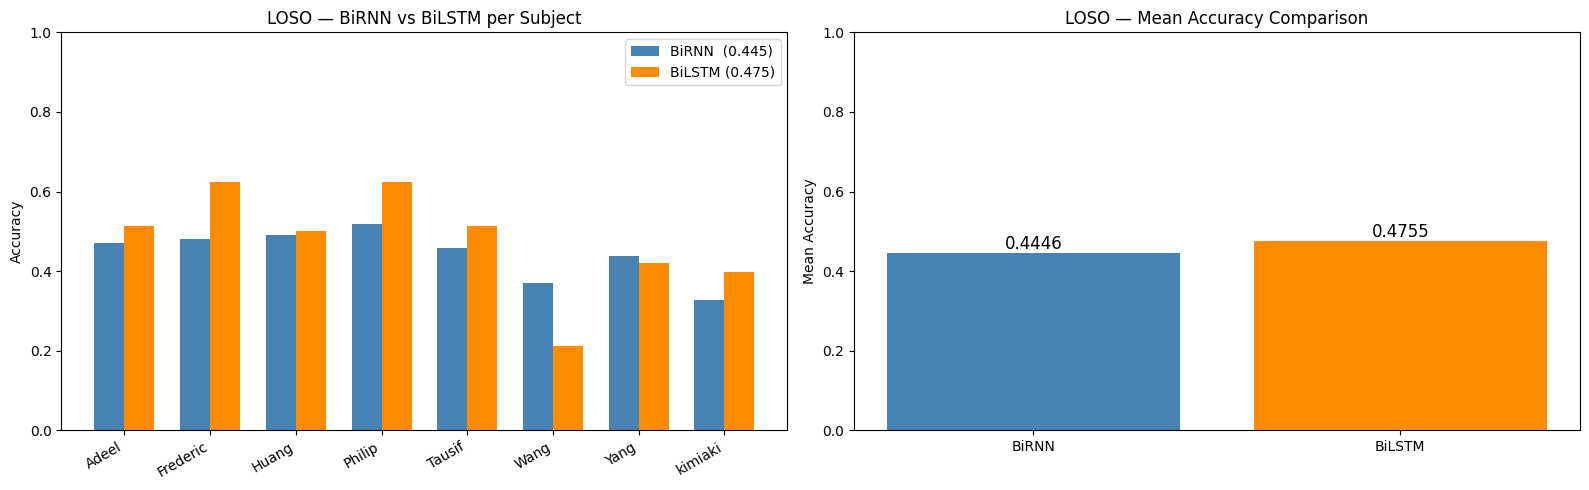


LOSO Final Summary:
  BiRNN  Early Fusion : 0.4446 ± 0.0647
  BiLSTM Early Fusion : 0.4755 ± 0.1345


In [45]:
# Plot

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(len(subjects))
w = 0.35

axes[0].bar(x - w/2, df_loso_rnn["accuracy"],  w,label=f"BiRNN  ({loso_rnn_mean:.3f})",  color="steelblue")
axes[0].bar(x + w/2, df_loso_lstm["accuracy"], w,label=f"BiLSTM ({loso_lstm_mean:.3f})", color="darkorange")

axes[0].set_xticks(x)
axes[0].set_xticklabels(subjects, rotation=30, ha="right")
axes[0].set_title("LOSO — BiRNN vs BiLSTM per Subject")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
axes[0].legend()

axes[1].bar(["BiRNN", "BiLSTM"],[loso_rnn_mean, loso_lstm_mean],color=["steelblue", "darkorange"])

axes[1].set_title("LOSO — Mean Accuracy Comparison")
axes[1].set_ylabel("Mean Accuracy")
axes[1].set_ylim(0, 1)
for i, v in enumerate([loso_rnn_mean, loso_lstm_mean]): axes[1].text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=12)
plt.tight_layout()
plt.show()

print("\nLOSO Final Summary:")
print("="*45)
print(f"  BiRNN  Early Fusion : {loso_rnn_mean:.4f} ± {loso_rnn_std:.4f}")
print(f"  BiLSTM Early Fusion : {loso_lstm_mean:.4f} ± {loso_lstm_std:.4f}")


# **Late fusion**

# **RNN -- Subject dependent and independent**

In [48]:
print("Late Fusion BiRNN  |  Subject Dependent")
print("="*60)

y_train_sd_cat = to_categorical(y_train_sd, n_classes)
y_test_sd_cat  = to_categorical(y_test_sd,  n_classes)

def build_rnn_modality(input_features):

    model = Sequential([
        Input(shape=(n_timesteps, input_features)),

        Bidirectional(SimpleRNN(32, return_sequences=True, kernel_regularizer=tf.keras.regularizers.l2(0.001))),
        Bidirectional(SimpleRNN(16, kernel_regularizer=tf.keras.regularizers.l2(0.001))),

        BatchNormalization(),
        Dropout(0.5),
        Dense(32, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        Dropout(0.4),
        Dense(n_classes, activation="softmax")
    ])

    model.compile(optimizer=Adam(0.0003, clipnorm=1.0), loss="categorical_crossentropy", metrics=["accuracy"])

    return model

callbacks_lf = [
     EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5,min_lr=1e-6, verbose=0)]

# Split by modality

X_tr_ph  = X_train_sd[:, :, phone_idx]
X_tr_and = X_train_sd[:, :, android_idx]
X_tr_jin = X_train_sd[:, :, jins_idx]
X_te_ph  = X_test_sd[:, :, phone_idx]
X_te_and = X_test_sd[:, :, android_idx]
X_te_jin = X_test_sd[:, :, jins_idx]

# Train 3 models

print("Training Phone model (15 features)...")
m_ph_rnn_sd = build_rnn_modality(15)
m_ph_rnn_sd.fit(X_tr_ph, y_train_sd_cat, epochs=100, batch_size=64,validation_data=(X_te_ph, y_test_sd_cat),callbacks=callbacks_lf, verbose=0)

print("Training Android model (6 features)...")
m_and_rnn_sd = build_rnn_modality(6)
m_and_rnn_sd.fit(X_tr_and, y_train_sd_cat, epochs=100, batch_size=64,validation_data=(X_te_and, y_test_sd_cat),callbacks=callbacks_lf, verbose=0)

print("Training JINS model (6 features)...")
m_jin_rnn_sd = build_rnn_modality(6)
m_jin_rnn_sd.fit(X_tr_jin, y_train_sd_cat, epochs=100, batch_size=64,validation_data=(X_te_jin, y_test_sd_cat),callbacks=callbacks_lf, verbose=0)

# Late fusion

pred_ph  = m_ph_rnn_sd.predict(X_te_ph,   verbose=0)
pred_and = m_and_rnn_sd.predict(X_te_and, verbose=0)
pred_jin = m_jin_rnn_sd.predict(X_te_jin, verbose=0)

pred_fused       = (pred_ph + pred_and + pred_jin) / 3
y_pred_lf_rnn_sd = np.argmax(pred_fused, axis=1)
acc_lf_rnn_sd    = accuracy_score(y_test_sd, y_pred_lf_rnn_sd)

print(f"\nLate Fusion BiRNN SD Accuracy: {acc_lf_rnn_sd:.4f}")
print("\nPer modality:")
print(f"  Phone   : {accuracy_score(y_test_sd, np.argmax(pred_ph,  axis=1)):.4f}")
print(f"  Android : {accuracy_score(y_test_sd, np.argmax(pred_and, axis=1)):.4f}")
print(f"  JINS    : {accuracy_score(y_test_sd, np.argmax(pred_jin, axis=1)):.4f}")
print(f"  Fused   : {acc_lf_rnn_sd:.4f}")

print(pd.DataFrame(classification_report(y_test_sd, y_pred_lf_rnn_sd,target_names=le.classes_, output_dict=True)).transpose().round(3).to_string())



Late Fusion BiRNN  |  Subject Dependent
Training Phone model (15 features)...
Training Android model (6 features)...
Training JINS model (6 features)...

Late Fusion BiRNN SD Accuracy: 0.6296

Per modality:
  Phone   : 0.4278
  Android : 0.4074
  JINS    : 0.4074
  Fused   : 0.6296
              precision  recall  f1-score  support
Bending           0.638   0.957     0.765    46.00
Bring             0.711   0.600     0.651    45.00
CleanFloor        0.534   0.646     0.585    48.00
CleanSurface      0.400   0.087     0.143    46.00
Drink             0.582   0.848     0.690    46.00
DryOffHand        0.600   0.419     0.493    43.00
EatSmall          0.583   0.609     0.596    46.00
Lying             0.764   0.977     0.857    43.00
Sitting           0.529   0.419     0.468    43.00
Squatting         0.757   0.651     0.700    43.00
Standing          0.556   0.543     0.549    46.00
Walking           0.735   0.800     0.766    45.00
accuracy          0.630   0.630     0.630     0.63
mac

In [49]:
print("Late Fusion BiRNN  |  Subject Independent")
print("Train: Huang  |  Test: Adeel")
print("="*60)

y_train_si_cat = to_categorical(y_train_si, n_classes)
y_test_si_cat  = to_categorical(y_test_si,  n_classes)

X_tr_ph  = X_train_si[:, :, phone_idx]
X_tr_and = X_train_si[:, :, android_idx]
X_tr_jin = X_train_si[:, :, jins_idx]
X_te_ph  = X_test_si[:, :, phone_idx]
X_te_and = X_test_si[:, :, android_idx]
X_te_jin = X_test_si[:, :, jins_idx]

print("Training Phone model...")
m_ph_rnn_si = build_rnn_modality(15)
m_ph_rnn_si.fit(X_tr_ph, y_train_si_cat, epochs=100, batch_size=64, validation_data=(X_te_ph, y_test_si_cat), callbacks=callbacks_lf, verbose=0)

print("Training Android model...")
m_and_rnn_si = build_rnn_modality(6)
m_and_rnn_si.fit(X_tr_and, y_train_si_cat, epochs=100, batch_size=64, validation_data=(X_te_and, y_test_si_cat), callbacks=callbacks_lf, verbose=0)

print("Training JINS model...")
m_jin_rnn_si = build_rnn_modality(6)
m_jin_rnn_si.fit(X_tr_jin, y_train_si_cat, epochs=100, batch_size=64, validation_data=(X_te_jin, y_test_si_cat), callbacks=callbacks_lf, verbose=0)

pred_ph  = m_ph_rnn_si.predict(X_te_ph,   verbose=0)
pred_and = m_and_rnn_si.predict(X_te_and, verbose=0)
pred_jin = m_jin_rnn_si.predict(X_te_jin, verbose=0)

pred_fused       = (pred_ph + pred_and + pred_jin) / 3
y_pred_lf_rnn_si = np.argmax(pred_fused, axis=1)
acc_lf_rnn_si    = accuracy_score(y_test_si, y_pred_lf_rnn_si)

print(f"\nLate Fusion BiRNN SI Accuracy: {acc_lf_rnn_si:.4f}")
print("\nPer modality:")
print(f"  Phone   : {accuracy_score(y_test_si, np.argmax(pred_ph,  axis=1)):.4f}")
print(f"  Android : {accuracy_score(y_test_si, np.argmax(pred_and, axis=1)):.4f}")
print(f"  JINS    : {accuracy_score(y_test_si, np.argmax(pred_jin, axis=1)):.4f}")
print(f"  Fused   : {acc_lf_rnn_si:.4f}")

print(pd.DataFrame(classification_report( y_test_si, y_pred_lf_rnn_si, target_names=le.classes_, output_dict=True )).transpose().round(3).to_string())


Late Fusion BiRNN  |  Subject Independent
Train: Huang  |  Test: Adeel
Training Phone model...
Training Android model...
Training JINS model...

Late Fusion BiRNN SI Accuracy: 0.3347

Per modality:
  Phone   : 0.2273
  Android : 0.3430
  JINS    : 0.1736
  Fused   : 0.3347
              precision  recall  f1-score  support
Bending           0.306   0.950     0.463   20.000
Bring             0.207   0.300     0.245   20.000
CleanFloor        0.143   0.095     0.114   21.000
CleanSurface      0.250   0.100     0.143   20.000
Drink             0.182   0.095     0.125   21.000
DryOffHand        0.000   0.000     0.000   20.000
EatSmall          0.333   0.050     0.087   20.000
Lying             0.645   1.000     0.784   20.000
Sitting           0.484   0.750     0.588   20.000
Squatting         0.000   0.000     0.000   20.000
Standing          0.174   0.200     0.186   20.000
Walking           0.625   0.500     0.556   20.000
accuracy          0.335   0.335     0.335    0.335
macro avg   

# **LSTM -- Dependent and independent**

In [50]:
print("Late Fusion BiLSTM  |  Subject Dependent")
print("="*60)

y_train_sd_cat = to_categorical(y_train_sd, n_classes)
y_test_sd_cat  = to_categorical(y_test_sd,  n_classes)

def build_lstm_modality(input_features):
    model = Sequential([
        Input(shape=(n_timesteps, input_features)),
        Bidirectional(LSTM(32, return_sequences=True, kernel_regularizer=tf.keras.regularizers.l2(0.001))),
        Bidirectional(LSTM(16,kernel_regularizer=tf.keras.regularizers.l2(0.001))),
        BatchNormalization(),
        Dropout(0.5),
        Dense(32, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        Dropout(0.4),
        Dense(n_classes, activation="softmax")
    ])

    model.compile(optimizer=Adam(0.0003, clipnorm=1.0),loss="categorical_crossentropy",metrics=["accuracy"])

    return model

X_tr_ph  = X_train_sd[:, :, phone_idx]
X_tr_and = X_train_sd[:, :, android_idx]
X_tr_jin = X_train_sd[:, :, jins_idx]
X_te_ph  = X_test_sd[:, :, phone_idx]
X_te_and = X_test_sd[:, :, android_idx]
X_te_jin = X_test_sd[:, :, jins_idx]

print("Training Phone model (15 features)...")
m_ph_lstm_sd = build_lstm_modality(15)
m_ph_lstm_sd.fit(X_tr_ph, y_train_sd_cat, epochs=100, batch_size=64, validation_data=(X_te_ph, y_test_sd_cat), callbacks=callbacks_lf, verbose=0)

print("Training Android model (6 features)...")
m_and_lstm_sd = build_lstm_modality(6)
m_and_lstm_sd.fit(X_tr_and, y_train_sd_cat, epochs=100, batch_size=64, validation_data=(X_te_and, y_test_sd_cat), callbacks=callbacks_lf, verbose=0)

print("Training JINS model (6 features)...")
m_jin_lstm_sd = build_lstm_modality(6)
m_jin_lstm_sd.fit(X_tr_jin, y_train_sd_cat, epochs=100, batch_size=64, validation_data=(X_te_jin, y_test_sd_cat), callbacks=callbacks_lf, verbose=0)

pred_ph  = m_ph_lstm_sd.predict(X_te_ph,   verbose=0)
pred_and = m_and_lstm_sd.predict(X_te_and, verbose=0)
pred_jin = m_jin_lstm_sd.predict(X_te_jin, verbose=0)

pred_fused        = (pred_ph + pred_and + pred_jin) / 3
y_pred_lf_lstm_sd = np.argmax(pred_fused, axis=1)
acc_lf_lstm_sd    = accuracy_score(y_test_sd, y_pred_lf_lstm_sd)

print(f"\nLate Fusion BiLSTM SD Accuracy: {acc_lf_lstm_sd:.4f}")
print("\nPer modality:")
print(f"  Phone   : {accuracy_score(y_test_sd, np.argmax(pred_ph,  axis=1)):.4f}")
print(f"  Android : {accuracy_score(y_test_sd, np.argmax(pred_and, axis=1)):.4f}")
print(f"  JINS    : {accuracy_score(y_test_sd, np.argmax(pred_jin, axis=1)):.4f}")
print(f"  Fused   : {acc_lf_lstm_sd:.4f}")

print(pd.DataFrame(classification_report( y_test_sd, y_pred_lf_lstm_sd, target_names=le.classes_, output_dict=True )).transpose().round(3).to_string())


Late Fusion BiLSTM  |  Subject Dependent
Training Phone model (15 features)...
Training Android model (6 features)...
Training JINS model (6 features)...

Late Fusion BiLSTM SD Accuracy: 0.7204

Per modality:
  Phone   : 0.5444
  Android : 0.4852
  JINS    : 0.4778
  Fused   : 0.7204
              precision  recall  f1-score  support
Bending           0.662   0.935     0.775    46.00
Bring             0.729   0.778     0.753    45.00
CleanFloor        0.574   0.646     0.608    48.00
CleanSurface      0.786   0.478     0.595    46.00
Drink             0.780   0.848     0.812    46.00
DryOffHand        0.771   0.628     0.692    43.00
EatSmall          0.702   0.717     0.710    46.00
Lying             0.768   1.000     0.869    43.00
Sitting           0.634   0.605     0.619    43.00
Squatting         0.780   0.744     0.762    43.00
Standing          0.806   0.543     0.649    46.00
Walking           0.750   0.733     0.742    45.00
accuracy          0.720   0.720     0.720     0.72
m

In [51]:
print("Late Fusion BiLSTM  |  Subject Independent")
print("Train: Huang  |  Test: Adeel")
print("="*60)

y_train_si_cat = to_categorical(y_train_si, n_classes)
y_test_si_cat  = to_categorical(y_test_si,  n_classes)

X_tr_ph  = X_train_si[:, :, phone_idx]
X_tr_and = X_train_si[:, :, android_idx]
X_tr_jin = X_train_si[:, :, jins_idx]
X_te_ph  = X_test_si[:, :, phone_idx]
X_te_and = X_test_si[:, :, android_idx]
X_te_jin = X_test_si[:, :, jins_idx]

print("Training Phone model...")
m_ph_lstm_si = build_lstm_modality(15)
m_ph_lstm_si.fit(X_tr_ph, y_train_si_cat, epochs=100, batch_size=64, validation_data=(X_te_ph, y_test_si_cat), callbacks=callbacks_lf, verbose=0)

print("Training Android model...")
m_and_lstm_si = build_lstm_modality(6)
m_and_lstm_si.fit(X_tr_and, y_train_si_cat, epochs=100, batch_size=64, validation_data=(X_te_and, y_test_si_cat), callbacks=callbacks_lf, verbose=0)

print("Training JINS model...")
m_jin_lstm_si = build_lstm_modality(6)
m_jin_lstm_si.fit(X_tr_jin, y_train_si_cat, epochs=100, batch_size=64, validation_data=(X_te_jin, y_test_si_cat),callbacks=callbacks_lf, verbose=0)

pred_ph  = m_ph_lstm_si.predict(X_te_ph,   verbose=0)
pred_and = m_and_lstm_si.predict(X_te_and, verbose=0)
pred_jin = m_jin_lstm_si.predict(X_te_jin, verbose=0)

pred_fused        = (pred_ph + pred_and + pred_jin) / 3
y_pred_lf_lstm_si = np.argmax(pred_fused, axis=1)
acc_lf_lstm_si    = accuracy_score(y_test_si, y_pred_lf_lstm_si)

print(f"\nLate Fusion BiLSTM SI Accuracy: {acc_lf_lstm_si:.4f}")
print("\nPer modality:")
print(f"  Phone   : {accuracy_score(y_test_si, np.argmax(pred_ph,  axis=1)):.4f}")
print(f"  Android : {accuracy_score(y_test_si, np.argmax(pred_and, axis=1)):.4f}")
print(f"  JINS    : {accuracy_score(y_test_si, np.argmax(pred_jin, axis=1)):.4f}")
print(f"  Fused   : {acc_lf_lstm_si:.4f}")

print(pd.DataFrame(classification_report(y_test_si, y_pred_lf_lstm_si, target_names=le.classes_, output_dict=True)).transpose().round(3).to_string())


Late Fusion BiLSTM  |  Subject Independent
Train: Huang  |  Test: Adeel
Training Phone model...
Training Android model...
Training JINS model...

Late Fusion BiLSTM SI Accuracy: 0.3967

Per modality:
  Phone   : 0.3017
  Android : 0.3099
  JINS    : 0.2562
  Fused   : 0.3967
              precision  recall  f1-score  support
Bending           0.455   1.000     0.625   20.000
Bring             0.312   0.250     0.278   20.000
CleanFloor        0.222   0.095     0.133   21.000
CleanSurface      0.125   0.050     0.071   20.000
Drink             0.500   0.429     0.462   21.000
DryOffHand        0.156   0.350     0.215   20.000
EatSmall          0.000   0.000     0.000   20.000
Lying             0.905   0.950     0.927   20.000
Sitting           0.516   0.800     0.627   20.000
Squatting         0.000   0.000     0.000   20.000
Standing          0.222   0.300     0.255   20.000
Walking           0.733   0.550     0.629   20.000
accuracy          0.397   0.397     0.397    0.397
macro avg 

In [52]:
# Final comparison

print("\nFinal Summary — Early vs Late Fusion:")
print("="*55)

print(f"{'Model':<30} {'SD':>10} {'SI':>10}")
print("-"*55)

print(f"{'BiRNN  Early Fusion':<30} {acc_rnn_sd:>10.4f} {acc_rnn_si:>10.4f}")
print(f"{'BiLSTM Early Fusion':<30} {acc_lstm_sd:>10.4f} {acc_lstm_si:>10.4f}")
print(f"{'BiRNN  Late  Fusion':<30} {acc_lf_rnn_sd:>10.4f} {acc_lf_rnn_si:>10.4f}")
print(f"{'BiLSTM Late  Fusion':<30} {acc_lf_lstm_sd:>10.4f} {acc_lf_lstm_si:>10.4f}")



Final Summary — Early vs Late Fusion:
Model                                  SD         SI
-------------------------------------------------------
BiRNN  Early Fusion                0.7148     0.2645
BiLSTM Early Fusion                0.7889     0.2975
BiRNN  Late  Fusion                0.6537     0.3347
BiLSTM Late  Fusion                0.7204     0.3967
